# **01**

In [ ]:
import numpy as np
#from keras.preprocessing.text import Tokenizer
from keras.preprocessing.sequence import pad_sequences
from keras.models import Sequential,Model
from keras.layers import Dense, Embedding, Flatten
import matplotlib.pyplot as plt

# 1) Charger les données
X_train = np.load("X_train.npy", allow_pickle=True)
y_train = np.load("y_train.npy", allow_pickle=True)
X_test = np.load("X_test.npy", allow_pickle=True)
y_test = np.load("y_test.npy", allow_pickle=True)


model1=Sequential()

model1.add(Dense(2,input_shape=(4,),activation='relu',kernel_initializer='normal'))
model1.add(Dense(1,activation='sigmoid'))
model1.compile(loss='binary_crossentropy',optimizer='adam',metrics=['accuracy'])

initial_weights=model1.get_weights()

In [ ]:
inp=model1.layers[0].input
out = model1.layers[0].output
inp_to_out= Model(inputs=inp,outputs=out)

y_pred= inp_to_out([X_test])

print(y_pred.shape)

(412, 2)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_20
Received: inputs=['Tensor(shape=(412, 4))']
  warnings.warn(msg)


/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_20
Received: inputs=['Tensor(shape=(412, 4))']
  warnings.warn(msg)


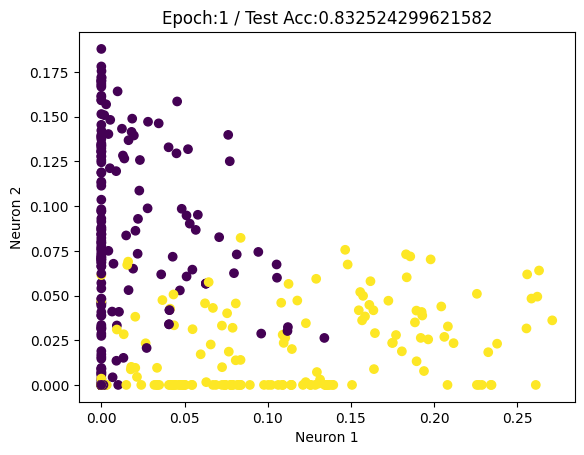

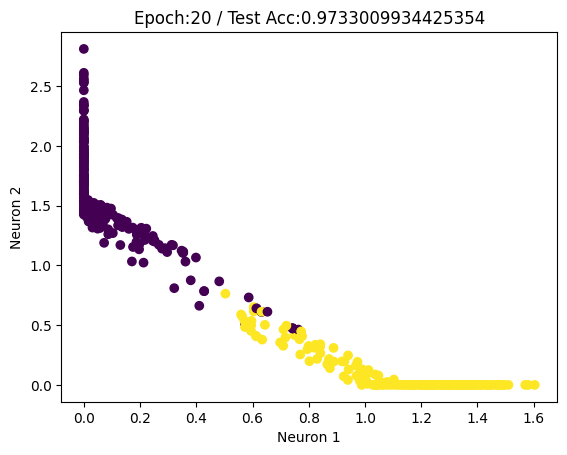

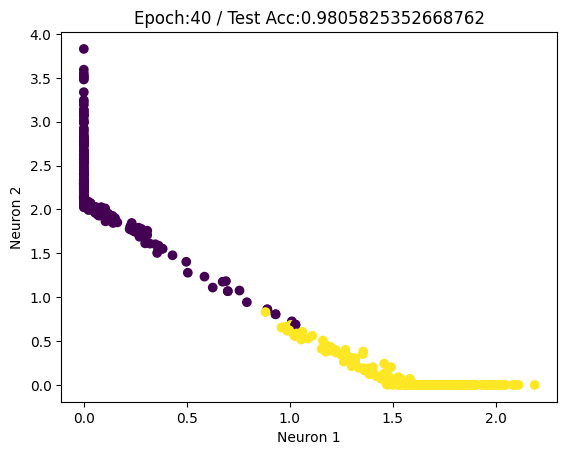

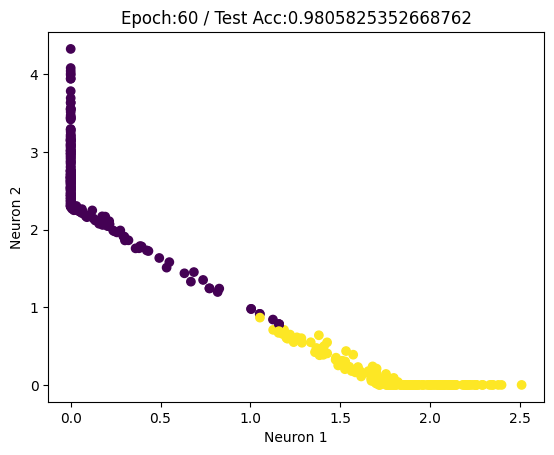

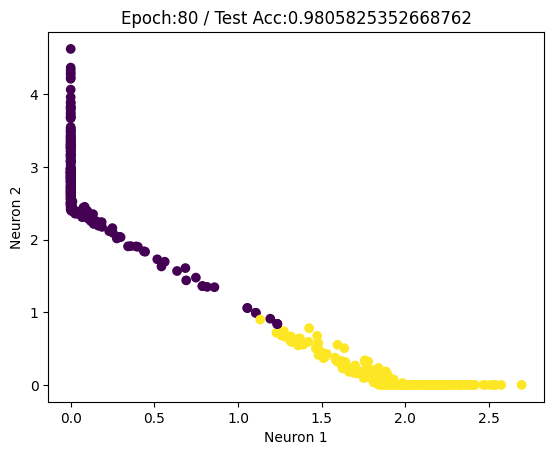

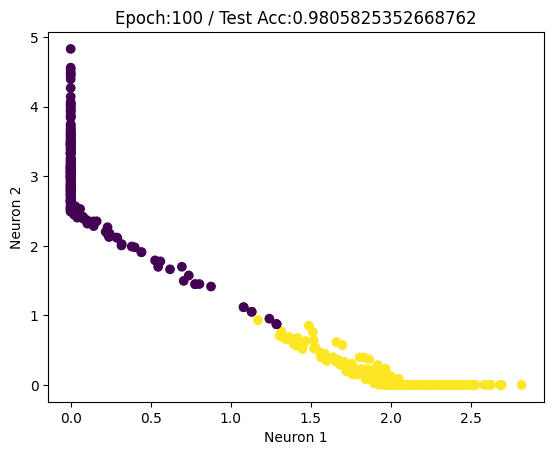

In [ ]:
import matplotlib.pyplot as plt
model1.set_weights(initial_weights)
n_epochs=100
for i in range (1,n_epochs+1):
  model1.fit(X_train,y_train,epochs=1,verbose=0)


  if i==1 or i%(n_epochs/5)==0:
    layer_output = inp_to_out([X_test])
    test_accuracy = model1.evaluate(X_test, y_test,verbose=0)[1]

    plt.figure()
    plt.scatter(layer_output[:, 0], layer_output[:, 1], c=y_test)
    plt.title('Epoch:{} / Test Acc:{}'.format(i,test_accuracy))
    plt.xlabel('Neuron 1')
    plt.ylabel('Neuron 2')
    plt.show()

 # **02**

In [ ]:
from keras.datasets import mnist
(X_train,y_train),(X_test,y_test)=mnist.load_data()
X_train= X_train/255. #norm(0,1)
X_test= X_test/255.

X_train=X_train.reshape(X_train.shape[0], -1) #2D--> 1D
X_test=X_test.reshape(X_test.shape[0], -1)


In [ ]:
autoencoder=Sequential()
autoencoder.add(Dense(32,input_shape=(784,),activation='relu'))
autoencoder.add(Dense(784,activation='sigmoid'))
autoencoder.compile(optimizer='adam',loss='binary_crossentropy')
autoencoder.fit(X_train,X_train,epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.2251
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.1090
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0972
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0954
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0948


In [ ]:
X_train.shape

(60000, 784)

In [ ]:
noise = np.random.normal(loc=0,scale=0.5,size=X_test.shape)
X_test_noisy=X_test+noise

decoded_ilages = autoencoder.predict(X_test_noisy,verbose=0)

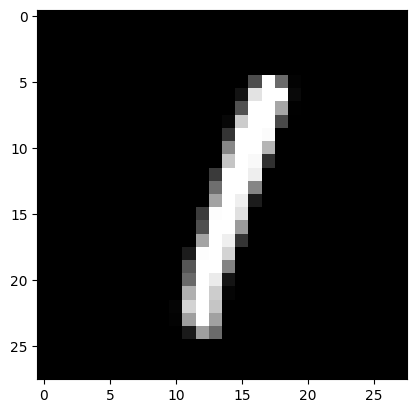

In [ ]:
plt.imshow(X_test[5].reshape(28,28),cmap='gray')

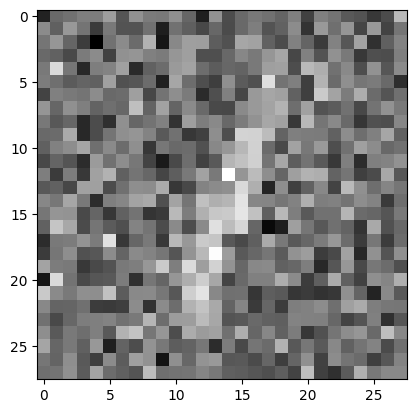

In [ ]:
plt.imshow(X_test_noisy[5].reshape(28,28),cmap='gray')

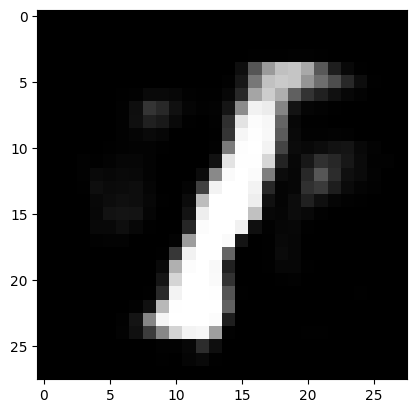

In [ ]:
plt.imshow(decoded_ilages[5].reshape(28,28),cmap='gray')

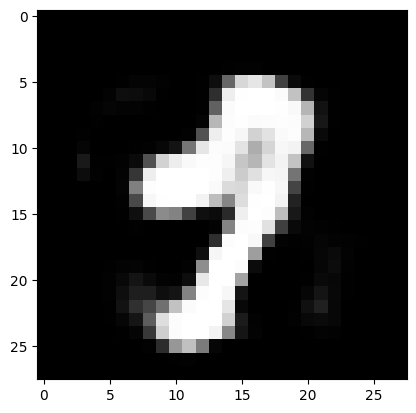

In [ ]:
plt.imshow(decoded_ilages[20].reshape(28,28),cmap='gray')

In [ ]:
y_test[20]

np.uint8(9)

# **03**

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 36s 19ms/step - accuracy: 0.8438 - loss: 0.5004 - val_accuracy: 0.9719 - val_loss: 0.0901
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9739 - loss: 0.0858 - val_accuracy: 0.9783 - val_loss: 0.0686
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 42s 19ms/step - accuracy: 0.9803 - loss: 0.0641 - val_accuracy: 0.9806 - val_loss: 0.0558
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9838 - loss: 0.0515 - val_accuracy: 0.9856 - val_loss: 0.0461
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 35s 19ms/step - accuracy: 0.9866 - loss: 0.0426 - val_accuracy: 0.9851 - val_loss: 0.0443


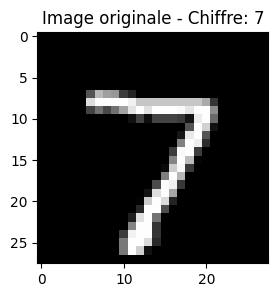

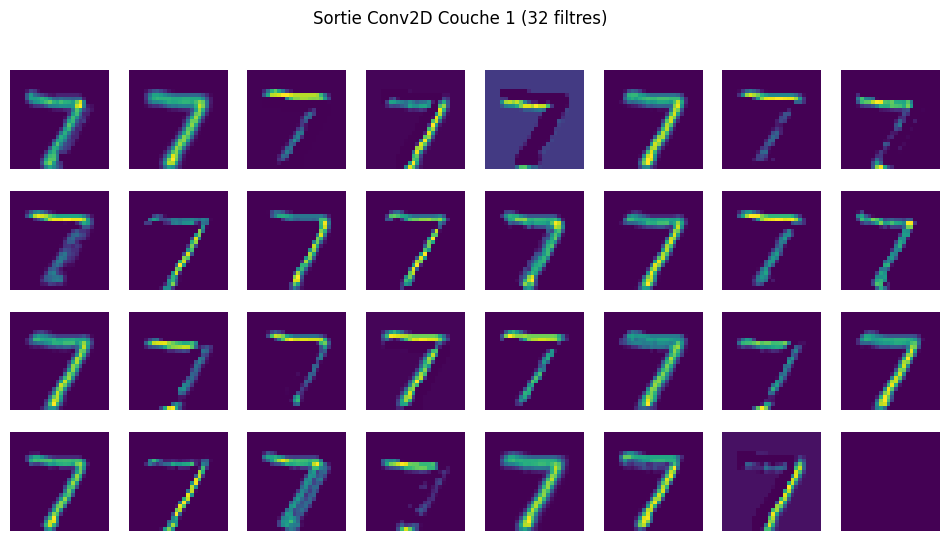

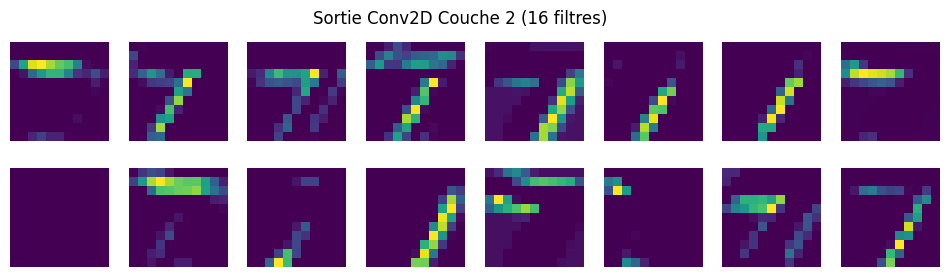

In [ ]:
import numpy as np
from keras.datasets import mnist
from keras.models import Sequential, Model
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.utils import to_categorical
import matplotlib.pyplot as plt

# 1) Charger les données
(X_train, y_train), (X_test, y_test) = mnist.load_data()
X_train = X_train.reshape(X_train.shape[0], 28, 28, 1) / 255.
X_test = X_test.reshape(X_test.shape[0], 28, 28, 1) / 255.
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

# 2) Créer le modèle CNN
model = Sequential()
model.add(Conv2D(32, (3,3), activation='relu', kernel_initializer='normal', input_shape=(28,28,1)))
model.add(MaxPooling2D(2))
model.add(Conv2D(16, (3,3), activation='relu'))
model.add(MaxPooling2D(2))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))

# 3) Compiler et entraîner
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])
model.fit(X_train, y_train_cat, epochs=5, validation_data=(X_test, y_test_cat))

# 4) Visualiser les sorties de convolutions
from keras.models import clone_model

conv1_model = Sequential()
conv1_model.add(model.layers[0])

conv2_model = Sequential()
conv2_model.add(model.layers[0])
conv2_model.add(model.layers[1])
conv2_model.add(model.layers[2])

test_image = X_test[0:1]
conv1_output = conv1_model.predict(test_image, verbose=0)
conv2_output = conv2_model.predict(test_image, verbose=0)

# Afficher l'image originale
plt.figure(figsize=(3,3))
plt.imshow(X_test[0].reshape(28,28), cmap='gray')
plt.title(f'Image originale - Chiffre: {y_test[0]}')
plt.show()

# Afficher les 32 filtres de la couche 1
fig, axes = plt.subplots(4, 8, figsize=(12,6))
for i in range(32):
    axes[i//8, i%8].imshow(conv1_output[0,:,:,i], cmap='viridis')
    axes[i//8, i%8].axis('off')
plt.suptitle('Sortie Conv2D Couche 1 (32 filtres)')
plt.show()

# Afficher les 16 filtres de la couche 2
fig, axes = plt.subplots(2, 8, figsize=(12,3))
for i in range(16):
    axes[i//8, i%8].imshow(conv2_output[0,:,:,i], cmap='viridis')
    axes[i//8, i%8].axis('off')
plt.suptitle('Sortie Conv2D Couche 2 (16 filtres)')
plt.show()

# **EXERCICE 04**

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 101s 53ms/step - loss: 0.1335
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 98s 52ms/step - loss: 0.0713
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 146s 54ms/step - loss: 0.0691
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 99s 53ms/step - loss: 0.0679
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 100s 53ms/step - loss: 0.0672


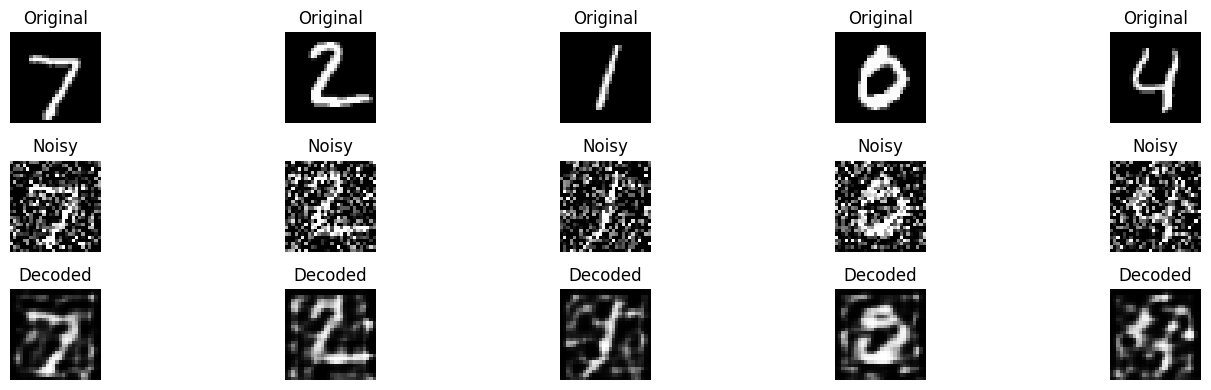

In [ ]:
from keras.datasets import mnist
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPooling2D, UpSampling2D, Flatten, Reshape
import matplotlib.pyplot as plt
import numpy as np

# Charger les données MNIST
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normaliser et redimensionner
X_train = X_train / 255.
X_test = X_test / 255.
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Créer l'autoencodeur convolutif
conv_autoencoder = Sequential()

# Encodeur
conv_autoencoder.add(Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(28, 28, 1)))
conv_autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))
conv_autoencoder.add(Conv2D(16, kernel_size=3, activation='relu', padding='same'))
conv_autoencoder.add(MaxPooling2D(pool_size=2, padding='same'))

# Décodeur
conv_autoencoder.add(Conv2D(16, kernel_size=3, activation='relu', padding='same'))
conv_autoencoder.add(UpSampling2D(size=2))
conv_autoencoder.add(Conv2D(32, kernel_size=3, activation='relu', padding='same'))
conv_autoencoder.add(UpSampling2D(size=2))
conv_autoencoder.add(Conv2D(1, kernel_size=3, activation='sigmoid', padding='same'))

# Compiler le modèle
conv_autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Entraîner l'autoencodeur
conv_autoencoder.fit(X_train, X_train, epochs=5, verbose=1)

# Ajouter du bruit aux images de test
noise = np.random.normal(loc=0, scale=0.5, size=X_test.shape)
X_test_noisy = X_test + noise
X_test_noisy = np.clip(X_test_noisy, 0., 1.)

# Décoder les images bruitées
decoded_images = conv_autoencoder.predict(X_test_noisy, verbose=0)

# Afficher les résultats
n = 5
plt.figure(figsize=(15, 4))
for i in range(n):
    # Image originale
    plt.subplot(3, n, i+1)
    plt.imshow(X_test[i].reshape(28, 28), cmap='gray')
    plt.title('Original')
    plt.axis('off')

    # Image bruitée
    plt.subplot(3, n, i+1+n)
    plt.imshow(X_test_noisy[i].reshape(28, 28), cmap='gray')
    plt.title('Noisy')
    plt.axis('off')

    # Image reconstruite
    plt.subplot(3, n, i+1+2*n)
    plt.imshow(decoded_images[i].reshape(28, 28), cmap='gray')
    plt.title('Decoded')
    plt.axis('off')

plt.tight_layout()
plt.show()